# Análise Exploratória de Dados (EDA)
## Predição de Churn em Telecomunicações

---

**Objetivo:** Investigar o dataset Telco Customer Churn para compreender a estrutura dos dados, identificar padrões e características de clientes com maior probabilidade de cancelamento (churn), e direcionar as etapas subsequentes de feature engineering e modelagem.

**Por que a EDA é essencial?**
Antes de treinar qualquer modelo, precisamos entender a distribuição das variáveis, a qualidade dos dados (valores ausentes, tipos incorretos, duplicatas) e quais features apresentam maior relação com o churn. Isso evita decisões de modelagem às cegas e orienta a criação de features mais informativas.

**Estrutura deste notebook:**
1. **Setup e Carregamento** — Importação de bibliotecas e dados
2. **Visão Geral dos Dados** — Tipos, dimensões e estatísticas descritivas
3. **Análise da Variável Alvo** — Distribuição de churn e desbalanceamento
4. **Qualidade dos Dados** — Valores ausentes, tipos incorretos e duplicatas
5. **Análise Univariada** — Distribuição individual de variáveis numéricas e categóricas
6. **Análise Bivariada** — Relação entre features e churn (cruzamentos)
7. **Information Value (IV)** — Ranking quantitativo do poder preditivo de cada variável
8. **Conclusões e Próximos Passos** — Síntese dos achados e recomendações

---

## 1. Setup e Carregamento

Importação das bibliotecas de análise e visualização, configuração dos paths do projeto e carregamento do dataset bruto. Os módulos auxiliares do projeto (`src/`) fornecem funções reutilizáveis de visualização e cálculo de Information Value.

In [8]:
# Bibliotecas padrão
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Path do projeto
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Módulos do projeto
from src.config import (
 DATA_DIR_RAW, FILENAME, TARGET, ID_COL,
 NUMERIC_FEATURES, CATEGORICAL_FEATURES
)
from src.notebook_utils import (
 plot_distribution_analysis,
 calculate_iv_categorical,
 calculate_iv_numeric,
 plot_churn_by_column
)

# Configurações de visualização
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

In [9]:
# Carregar dados
df = pd.read_csv(DATA_DIR_RAW / FILENAME)
print(f"Dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Dataset: 7,043 linhas × 21 colunas


## 2. Visão Geral dos Dados

Primeira inspeção do dataset para entender dimensões, tipos de variáveis e estatísticas resumo. Essa etapa responde: *quantas variáveis temos? Quais são numéricas e quais categóricas? Os tipos estão corretos?*

In [10]:
# Primeiras linhas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# Tipos e info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
# Estatísticas descritivas
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Análise da Variável Alvo

A variável target (`Churn`) indica se o cliente cancelou o serviço. É fundamental verificar a **distribuição de classes** antes de escolher métricas e estratégias de modelagem — um dataset desbalanceado exige cuidados como stratified split, class weights ou reamostragem.

In [13]:
# Distribuição do target
churn_counts = df[TARGET].value_counts()
churn_pct = df[TARGET].value_counts(normalize=True) * 100

# Compatível com target como string ('No'/'Yes') ou numérico (0/1)
if set(churn_counts.index).issubset({0, 1}):
 no_count, yes_count = churn_counts.get(0, 0), churn_counts.get(1, 0)
 no_pct, yes_pct = churn_pct.get(0, 0), churn_pct.get(1, 0)
else:
 no_count, yes_count = churn_counts.get('No', 0), churn_counts.get('Yes', 0)
 no_pct, yes_pct = churn_pct.get('No', 0), churn_pct.get('Yes', 0)

print("Distribuição de Churn:")
print(f" - No: {no_count:,} ({no_pct:.1f}%)")
print(f" - Yes: {yes_count:,} ({yes_pct:.1f}%)")
print("\nDataset desbalanceado — usar F1-Score como métrica principal")

Distribuição de Churn:
 - No: 5,174 (73.5%)
 - Yes: 1,869 (26.5%)

Dataset desbalanceado — usar F1-Score como métrica principal


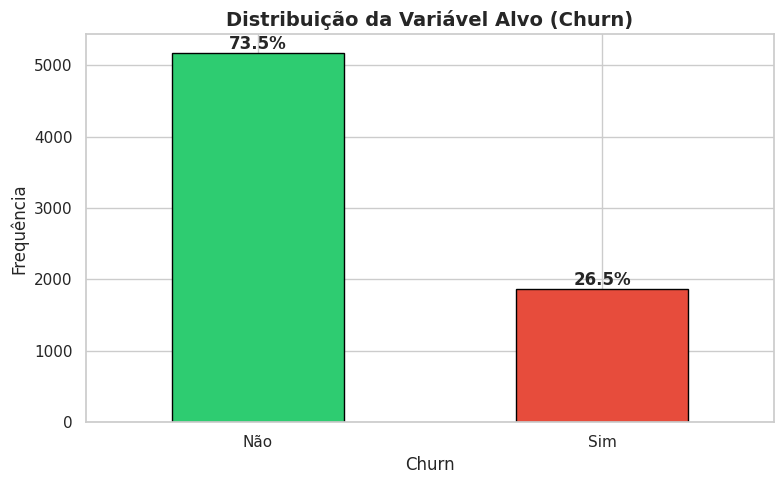

In [14]:
# Visualização
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
df[TARGET].value_counts().plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Distribuição da Variável Alvo (Churn)', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Frequência')
ax.set_xticklabels(['Não', 'Sim'], rotation=0)

# Adicionar percentuais
for i, (count, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
 ax.text(i, count + 50, f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [15]:
# Converter para numérico
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print("Target convertido: 0=No, 1=Yes")

Target convertido: 0=No, 1=Yes


## 4. Qualidade dos Dados

Antes de qualquer análise, verificamos a integridade dos dados:
- **Valores ausentes** — campos nulos ou vazios que precisam de tratamento
- **Tipos incorretos** — variáveis armazenadas com tipo errado (ex: numérica como string)
- **Duplicatas** — registros repetidos que podem inflar resultados

In [16]:
# Verificar valores ausentes iniciais
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({
 'Nulos': missing,
 '%': missing_pct.round(2)
})
missing_with_nulls = missing_summary[missing_summary['Nulos'] > 0]

if len(missing_with_nulls) == 0:
 print("Nenhum valor nulo detectado")
else:
 print("Valores ausentes:")
 print(missing_with_nulls)

Nenhum valor nulo detectado


### Investigação: `TotalCharges` como `object`

Embora não haja valores nulos detectados pela verificação padrão, uma análise mais cuidadosa revela que a coluna `TotalCharges` está armazenada como `object` (string) quando deveria ser `float`. Isso indica a presença de valores não numéricos "escondidos" — tipicamente strings vazias com espaço (`' '`) que o pandas não reconhece como `NaN`.

In [17]:
# TotalCharges está como object (string) - investigar valores não numéricos
print("Investigando TotalCharges:")
print(f" - Tipo atual: {df['TotalCharges'].dtype}")
print(f" - Valores únicos: {df['TotalCharges'].nunique()}")

# Identificar valores que não são numéricos (strings vazias ou com espaços)
non_numeric_mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
non_numeric_values = df.loc[non_numeric_mask, 'TotalCharges']

print(f"\nValores não numéricos encontrados: {len(non_numeric_values)}")
print(f" - Valores únicos: {non_numeric_values.unique()}")
print(f" - Representação: {[repr(v) for v in non_numeric_values.unique()]}")
print("\n → São STRINGS VAZIAS COM ESPAÇO (' '), não nulos!")

Investigando TotalCharges:
 - Tipo atual: object
 - Valores únicos: 6531

Valores não numéricos encontrados: 11
 - Valores únicos: [' ']
 - Representação: ["' '"]

 → São STRINGS VAZIAS COM ESPAÇO (' '), não nulos!


In [18]:
# Converter para numérico (espaços viram NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Analisar o padrão dos valores ausentes
missing_charges = df[df['TotalCharges'].isna()]

print("Análise dos registros com TotalCharges ausente:\n")
print(f" Total de registros: {len(missing_charges)}")
print(f"\n Distribuição de tenure:")
print(f" {missing_charges['tenure'].value_counts().to_dict()}")

# Verificar se TODOS têm tenure == 0
all_tenure_zero = (missing_charges['tenure'] == 0).all()
print(f"\n100% com tenure=0: {all_tenure_zero}")
print(f"\nCONCLUSÃO: São NOVOS CLIENTES (tenure=0) que ainda não receberam cobrança.")
print(" → Missing NOT at Random (MNAR) - valores ausentes são ESTRUTURAIS, não aleatórios.")

Análise dos registros com TotalCharges ausente:

 Total de registros: 11

 Distribuição de tenure:
 {0: 11}

100% com tenure=0: True

CONCLUSÃO: São NOVOS CLIENTES (tenure=0) que ainda não receberam cobrança.
 → Missing NOT at Random (MNAR) - valores ausentes são ESTRUTURAIS, não aleatórios.


### Tratamento: Preenchimento com zero

Como todos os registros com `TotalCharges` ausente são clientes novos (`tenure=0`) que ainda não receberam cobrança, o valor correto é **zero** — trata-se de um missing estrutural (MNAR), não de dado perdido aleatoriamente. Também verificamos a presença de duplicatas no identificador.

In [19]:
# TRATAMENTO: preencher com 0 (clientes novos sem cobrança)
df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = 0
print("TotalCharges preenchido com 0 para novos clientes (tenure=0)")

# Verificar duplicatas
n_duplicates = df[ID_COL].duplicated().sum()
print(f"Duplicatas no ID: {n_duplicates}")
print(f"Dataset sem valores ausentes: {df.isnull().sum().sum() == 0}")

TotalCharges preenchido com 0 para novos clientes (tenure=0)
Duplicatas no ID: 0
Dataset sem valores ausentes: True


## 5. Análise Univariada

Examinamos a distribuição de cada variável **individualmente**, sem cruzar com o target. O objetivo é entender a forma das distribuições (simetria, bimodalidade, outliers), identificar concentrações e verificar se há categorias dominantes ou variáveis com pouca variabilidade.

### 5.1 Variáveis Numéricas

O dataset possui três variáveis numéricas principais: `tenure` (meses de permanência), `MonthlyCharges` (cobrança mensal) e `TotalCharges` (total acumulado). Analisamos estatísticas descritivas e histogramas com mediana para identificar forma, dispersão e possíveis outliers.

In [20]:
# Estatísticas das numéricas
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


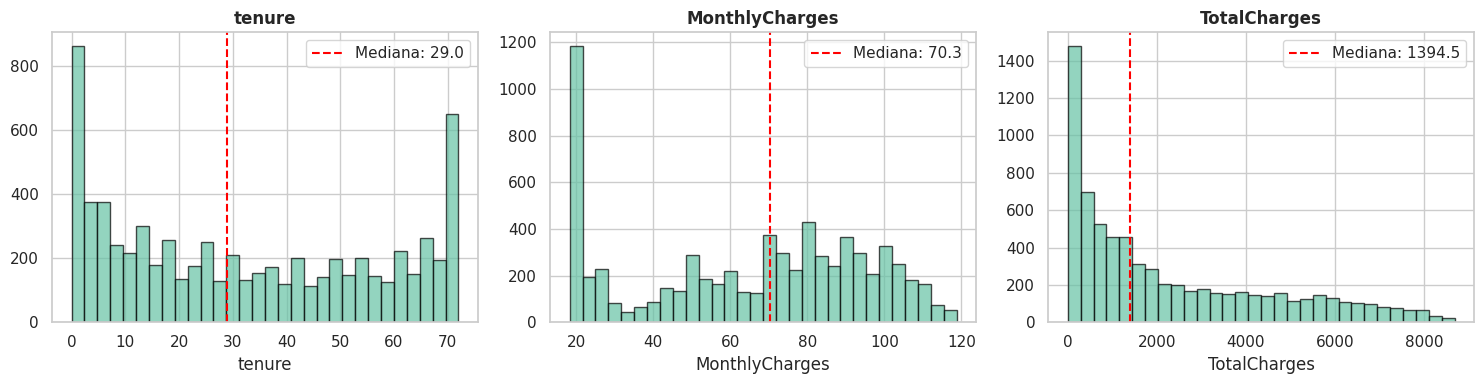

Observações:
 - tenure: Distribuição bimodal (novos e antigos)
 - MonthlyCharges: Distribuição aproximadamente uniforme
 - TotalCharges: Assimetria à direita (esperado)


In [21]:
# Distribuições
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numeric_cols):
 axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
 axes[i].set_title(col, fontsize=12, fontweight='bold')
 axes[i].set_xlabel(col)
 axes[i].axvline(df[col].median(), color='red', linestyle='--', label=f'Mediana: {df[col].median():.1f}')
 axes[i].legend()

plt.tight_layout()
plt.show()

print("Observações:")
print(" - tenure: Distribuição bimodal (novos e antigos)")
print(" - MonthlyCharges: Distribuição aproximadamente uniforme")
print(" - TotalCharges: Assimetria à direita (esperado)")

### 5.2 Variáveis Categóricas

Verificamos a distribuição de frequência de cada variável categórica para identificar categorias dominantes, variáveis com baixa cardinalidade (poucas categorias) e possíveis desequilíbrios que possam impactar a modelagem.

In [22]:
# Identificar categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != ID_COL]
print(f"Variáveis categóricas: {len(cat_cols)}")
print(cat_cols)

Variáveis categóricas: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


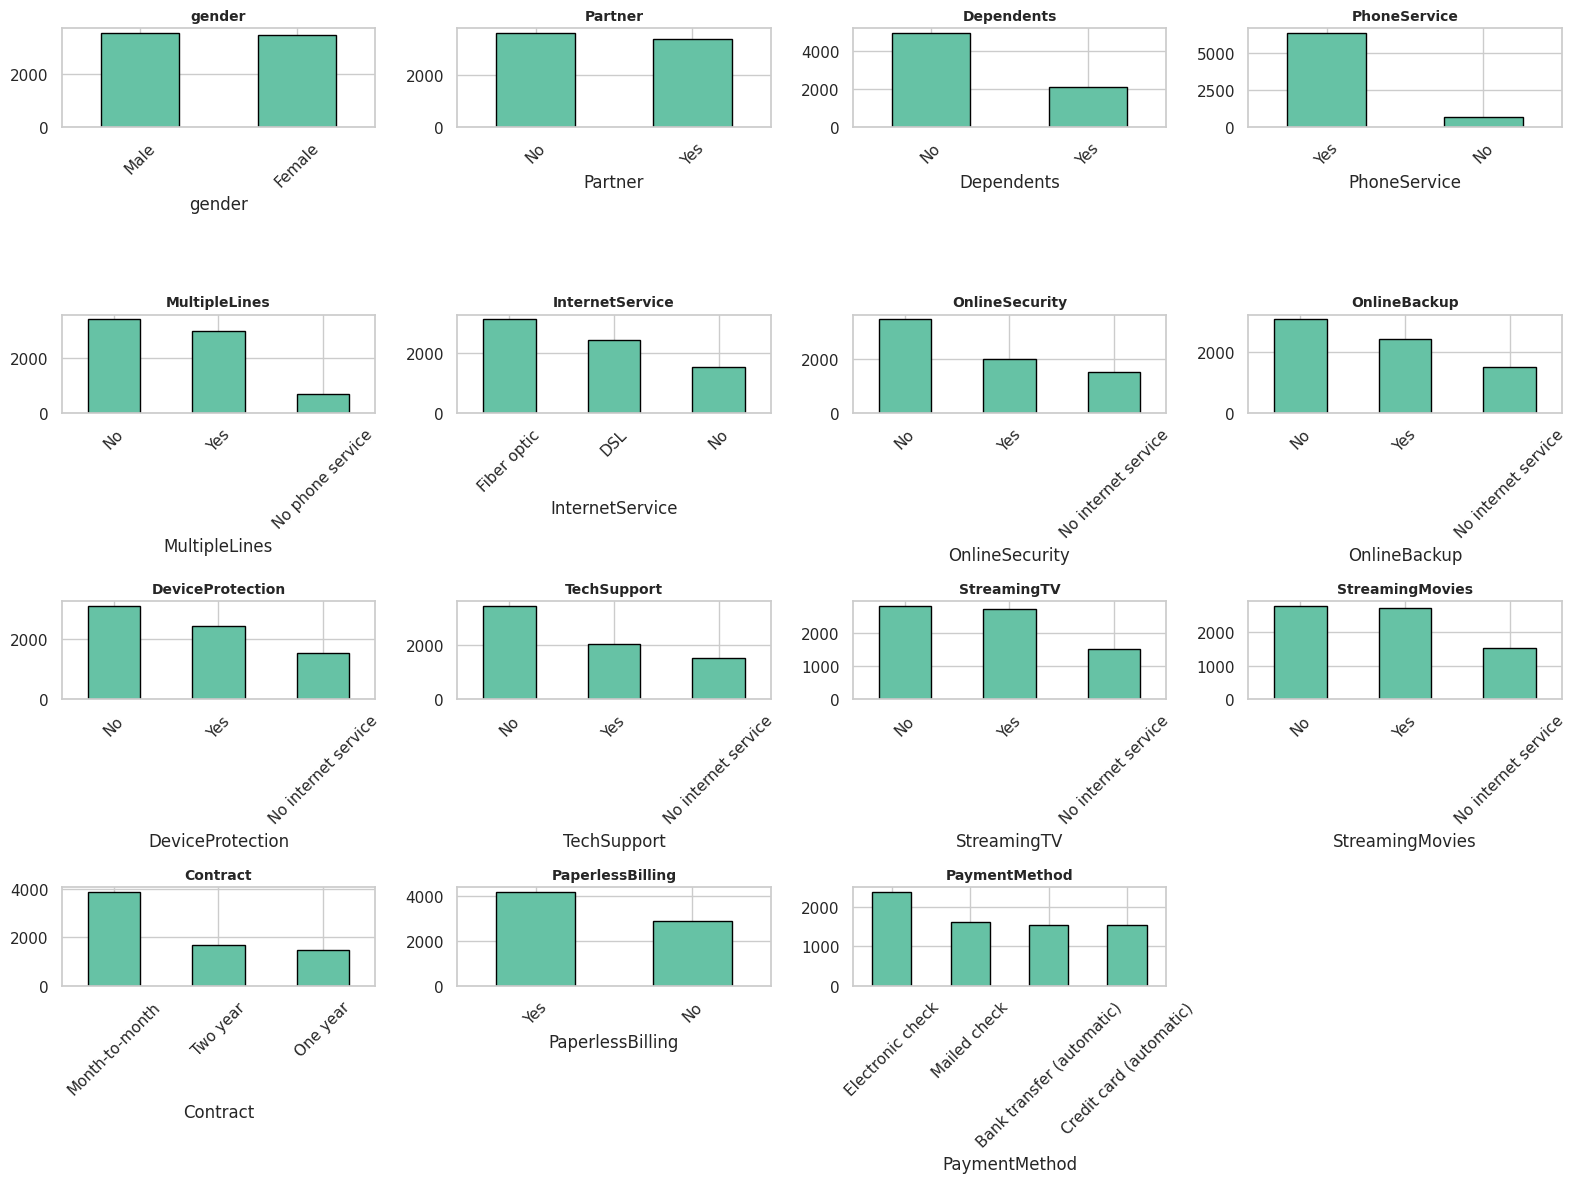

In [23]:
# Painel de distribuições categóricas
n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
 df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
 axes[i].set_title(col, fontsize=10, fontweight='bold')
 axes[i].tick_params(axis='x', rotation=45)

# Esconder eixos vazios
for j in range(len(cat_cols), len(axes)):
 axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Análise Bivariada (Features vs Churn)

Agora cruzamos cada feature com a variável target para identificar quais variáveis apresentam **maior diferenciação entre clientes que cancelam e os que permanecem**. Esta é a etapa mais importante da EDA para orientar a feature engineering e seleção de variáveis.

### 6.1 Numéricas vs Churn

Comparamos as distribuições das variáveis numéricas entre clientes que cancelaram e os que permaneceram, usando médias por grupo e boxplots. Diferenças significativas indicam poder discriminativo da variável.

In [24]:
# Comparação de médias
print("Médias por Grupo (Churn vs No Churn):\n")
comparison = df.groupby('Churn')[numeric_cols].mean().T
comparison.columns = ['No Churn', 'Churn']
comparison['Diferença %'] = ((comparison['Churn'] - comparison['No Churn']) / comparison['No Churn'] * 100).round(1)
comparison

Médias por Grupo (Churn vs No Churn):



,No Churn,Churn,Diferença %
tenure,37.569965,17.979133,-52.1
MonthlyCharges,61.265124,74.441332,21.5
TotalCharges,2549.911442,1531.796094,-39.9


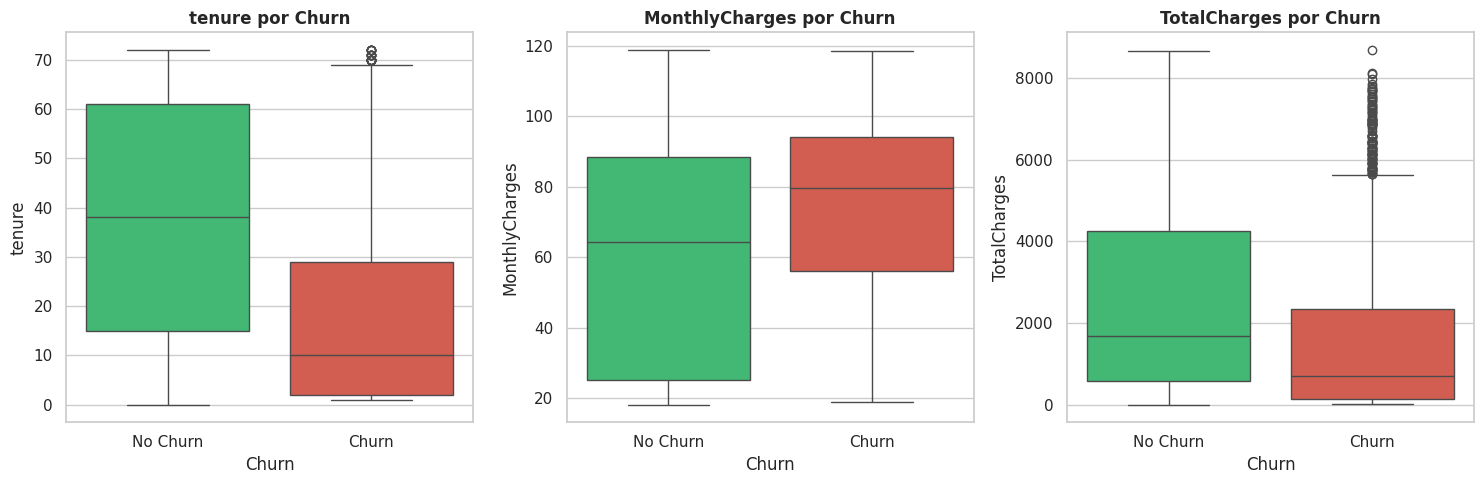


Insights:
 - tenure: Clientes que cancelam têm MENOR tempo (10 vs 38 meses)
 - MonthlyCharges: Clientes que cancelam pagam MAIS ($79 vs $61)
 - TotalCharges: Clientes que cancelam têm MENOR acumulado


In [25]:
# Boxplots comparativos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numeric_cols):
 sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
 axes[i].set_title(f'{col} por Churn', fontsize=12, fontweight='bold')
 axes[i].set_xticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

print("\nInsights:")
print(" - tenure: Clientes que cancelam têm MENOR tempo (10 vs 38 meses)")
print(" - MonthlyCharges: Clientes que cancelam pagam MAIS ($79 vs $61)")
print(" - TotalCharges: Clientes que cancelam têm MENOR acumulado")

### 6.2 Categóricas vs Churn

Calculamos a **taxa de churn por categoria** para cada variável e comparamos com a taxa base (~26.5%). Categorias com taxa muito acima da média indicam segmentos de alto risco.

In [26]:
# Função para calcular taxa de churn por categoria
def churn_rate_by_category(df, col):
 return df.groupby(col)['Churn'].mean().sort_values(ascending=False)

# Top features por taxa de churn
print("Taxa de Churn por Categoria (Top Features):\n")

key_features = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']
for col in key_features:
    print(f"\n{col}:")
    rates = churn_rate_by_category(df, col)
    for cat, rate in rates.items():
      print(f" - {cat}: {rate:.1%}")

Taxa de Churn por Categoria (Top Features):


Contract:
 - Month-to-month: 42.7%
 - One year: 11.3%
 - Two year: 2.8%

InternetService:
 - Fiber optic: 41.9%
 - DSL: 19.0%
 - No: 7.4%

PaymentMethod:
 - Electronic check: 45.3%
 - Mailed check: 19.1%
 - Bank transfer (automatic): 16.7%
 - Credit card (automatic): 15.2%

OnlineSecurity:
 - No: 41.8%
 - Yes: 14.6%
 - No internet service: 7.4%

TechSupport:
 - No: 41.6%
 - Yes: 15.2%
 - No internet service: 7.4%


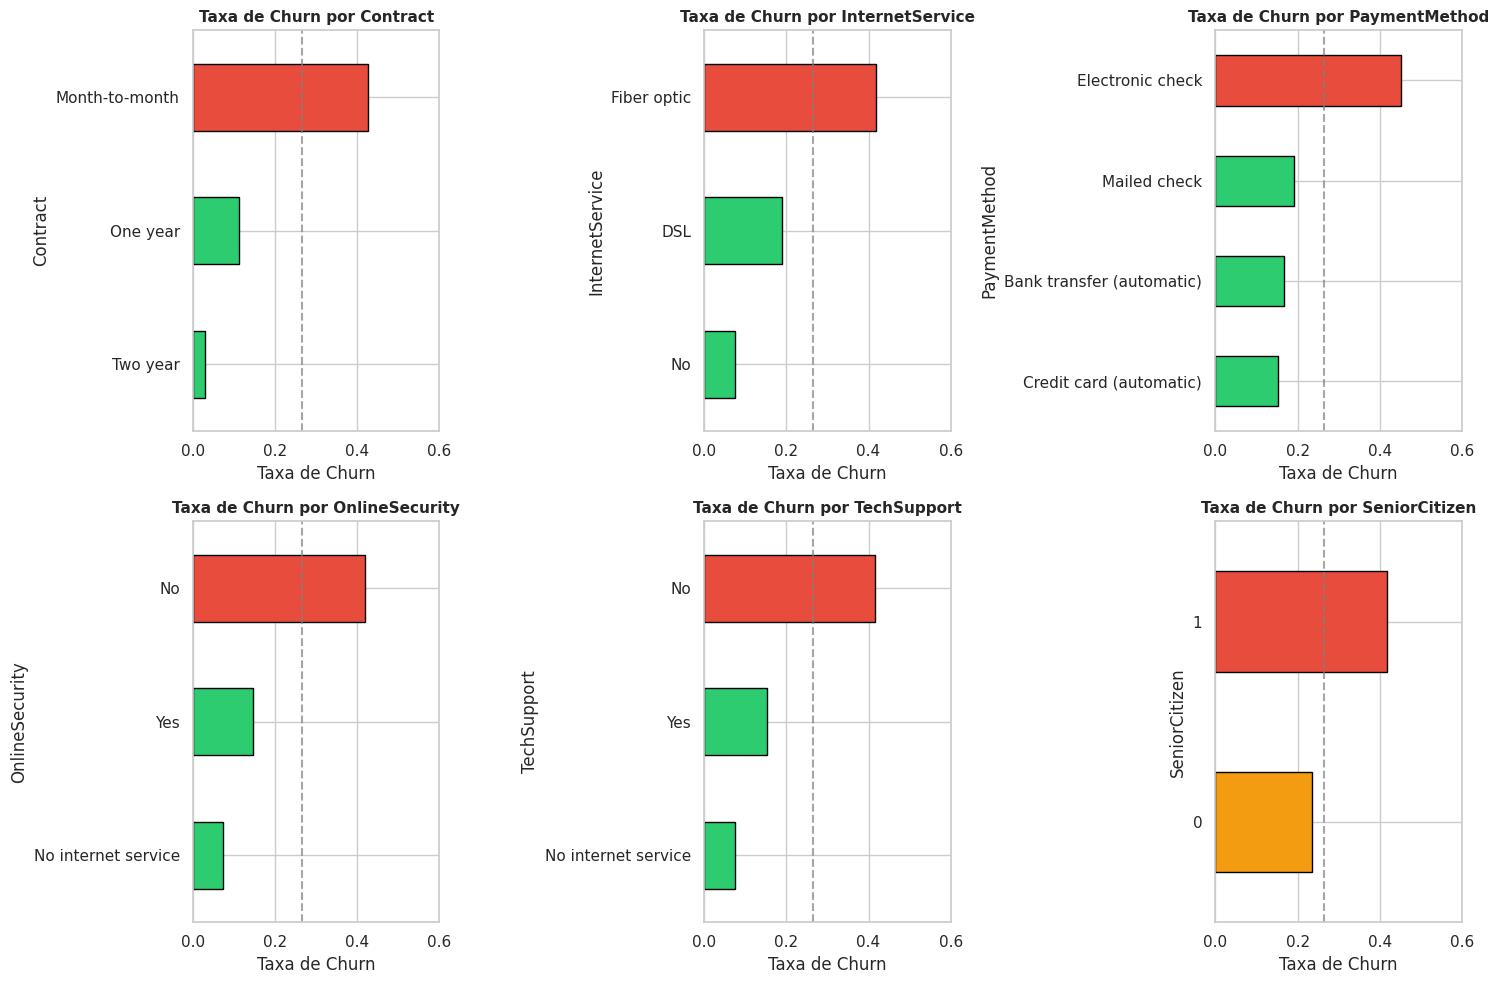

In [27]:
# Visualização das principais features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_features + ['SeniorCitizen']):
 churn_rates = df.groupby(col)['Churn'].mean().sort_values(ascending=True)
 colors = ['#e74c3c' if r > 0.3 else '#f39c12' if r > 0.2 else '#2ecc71' for r in churn_rates.values]
 
 churn_rates.plot(kind='barh', ax=axes[i], color=colors, edgecolor='black')
 axes[i].set_title(f'Taxa de Churn por {col}', fontsize=11, fontweight='bold')
 axes[i].set_xlabel('Taxa de Churn')
 axes[i].axvline(x=0.265, color='gray', linestyle='--', alpha=0.7, label='Média geral')
 axes[i].set_xlim(0, 0.6)

plt.tight_layout()
plt.show()

### 6.3 Insights Principais

A tabela abaixo resume as categorias com maior taxa de churn — todas significativamente acima da média geral de 26.5%:

| Feature | Categoria de Risco | Taxa de Churn | Fator vs Média |
|---------|-------------------|---------------|----------------|
| **Contract** | Month-to-month | 43% | 1.6x |
| **InternetService** | Fiber optic | 42% | 1.6x |
| **PaymentMethod** | Electronic check | 45% | 1.7x |
| **OnlineSecurity** | No | 42% | 1.6x |
| **TechSupport** | No | 42% | 1.6x |
| **SeniorCitizen** | Yes (1) | 41% | 1.5x |

**Padrão emergente:** O perfil de alto risco combina contrato mensal, internet de fibra óptica sem serviços de proteção, e pagamento via cheque eletrônico — sugerindo clientes com menor comprometimento e menor "lock-in" com a operadora.

## 7. Information Value (IV)

O **Information Value** é uma métrica estatística originada em credit scoring que quantifica o **poder preditivo** de cada variável em relação ao target. Diferente de correlação simples, o IV captura relações não-lineares e funciona tanto para variáveis numéricas (via binning) quanto categóricas.

**Escala de interpretação:**
| Faixa de IV | Classificação | Interpretação |
|-------------|---------------|---------------|
| < 0.02 | Irrelevante | Variável sem valor preditivo — candidata a descarte |
| 0.02 – 0.10 | Fraco | Contribuição marginal — avaliar caso a caso |
| 0.10 – 0.30 | Médio | Poder preditivo moderado — incluir no modelo |
| 0.30 – 0.50 | Forte | Alta capacidade discriminativa — feature prioritária |
| > 0.50 | Muito forte | Suspeita de data leakage — investigar causalidade |

In [28]:
# Calcular IV para todas as features
iv_results = []

# Categóricas
for col in cat_cols:
 iv = calculate_iv_categorical(df, col, 'Churn')
 iv_results.append({'Feature': col, 'IV': iv, 'Tipo': 'Categórica'})

# Numéricas
for col in numeric_cols:
 iv = calculate_iv_numeric(df, col, 'Churn')
 iv_results.append({'Feature': col, 'IV': iv, 'Tipo': 'Numérica'})

# DataFrame ordenado
iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False).reset_index(drop=True)

# Classificação
def classify_iv(iv):
 if iv < 0.02: return 'Irrelevante'
 elif iv < 0.1: return 'Fraco'
 elif iv < 0.3: return 'Médio'
 elif iv < 0.5: return 'Forte'
 else: return 'Muito Forte'

iv_df['Classificação'] = iv_df['IV'].apply(classify_iv)
iv_df

,Feature,IV,Tipo,Classificação
0,Contract,1.234133,Categórica,Muito Forte
1,tenure,0.828516,Numérica,Muito Forte
2,OnlineSecurity,0.716063,Categórica,Muito Forte
3,TechSupport,0.697891,Categórica,Muito Forte
4,InternetService,0.616479,Categórica,Muito Forte
5,OnlineBackup,0.527278,Categórica,Muito Forte
6,DeviceProtection,0.498404,Categórica,Forte
7,PaymentMethod,0.456146,Categórica,Forte
8,StreamingMovies,0.380214,Categórica,Forte
9,StreamingTV,0.379302,Categórica,Forte


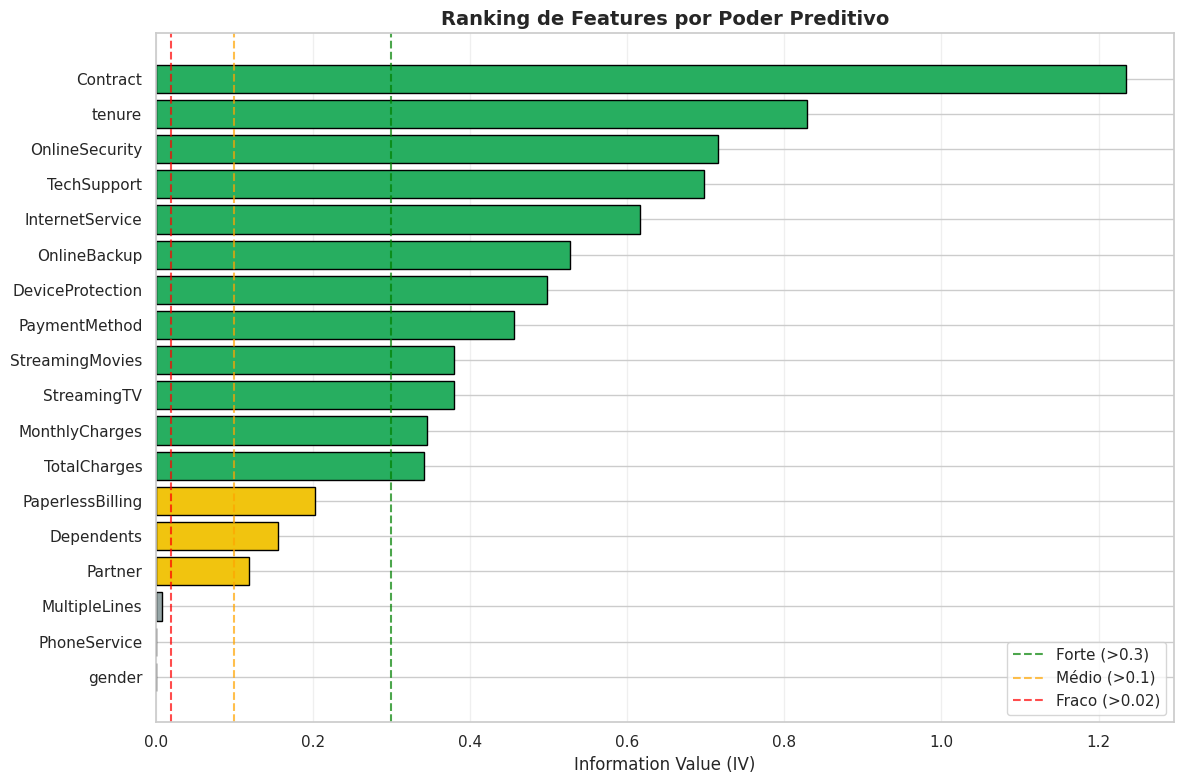

In [29]:
# Visualização do IV
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#27ae60' if iv >= 0.3 else '#f1c40f' if iv >= 0.1 else '#95a5a6' for iv in iv_df['IV']]
bars = ax.barh(iv_df['Feature'], iv_df['IV'], color=colors, edgecolor='black')

ax.axvline(x=0.3, color='green', linestyle='--', alpha=0.7, label='Forte (>0.3)')
ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Médio (>0.1)')
ax.axvline(x=0.02, color='red', linestyle='--', alpha=0.7, label='Fraco (>0.02)')

ax.set_xlabel('Information Value (IV)', fontsize=12)
ax.set_title('Ranking de Features por Poder Preditivo', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Top 10 features
print("TOP 10 FEATURES POR INFORMATION VALUE:\n")
for i, row in iv_df.head(10).iterrows():
 print(f" {i+1}. {row['Feature']:20s} | IV: {row['IV']:.4f} | {row['Classificação']}")

TOP 10 FEATURES POR INFORMATION VALUE:

 1. Contract             | IV: 1.2341 | Muito Forte
 2. tenure               | IV: 0.8285 | Muito Forte
 3. OnlineSecurity       | IV: 0.7161 | Muito Forte
 4. TechSupport          | IV: 0.6979 | Muito Forte
 5. InternetService      | IV: 0.6165 | Muito Forte
 6. OnlineBackup         | IV: 0.5273 | Muito Forte
 7. DeviceProtection     | IV: 0.4984 | Forte
 8. PaymentMethod        | IV: 0.4561 | Forte
 9. StreamingMovies      | IV: 0.3802 | Forte
 10. StreamingTV          | IV: 0.3793 | Forte


## 8. Conclusões e Próximos Passos

Síntese dos achados da EDA com recomendações práticas para feature engineering e modelagem.

### Resumo Executivo

**Dataset:**
- 7.043 clientes, 21 variáveis (17 categóricas + 3 numéricas + 1 ID)
- Taxa de churn: **26.5%** — dataset moderadamente desbalanceado, o que impacta a escolha de métricas (F1-Score > Accuracy) e estratégias de treino (stratified split, class weights)
- Sem duplicatas; um único problema de qualidade (`TotalCharges` como string) corrigido

---

### Perfil de Alto Risco de Churn

| Característica | Valor | Taxa de Churn | Interpretação |
|---------------|-------|---------------|---------------|
| Contrato | Month-to-month | 43% | Sem compromisso de longo prazo |
| Internet | Fiber optic | 42% | Possível insatisfação com custo-benefício |
| Pagamento | Electronic check | 45% | Associado a menor engajamento |
| Tenure | < 12 meses | ~50% | Clientes novos mais propensos a sair |
| Segurança Online | Não tem | 42% | Menor percepção de valor dos serviços |
| Suporte Técnico | Não tem | 42% | Sem suporte = maior frustração |

---

### Features Mais Importantes (IV > 0.3)

1. **Contract** — Tipo de contrato (mensal vs anual)
2. **OnlineSecurity** — Presença de serviço de segurança online
3. **TechSupport** — Acesso a suporte técnico
4. **tenure** — Tempo de permanência como cliente
5. **InternetService** — Tipo de serviço de internet

---

### Recomendações para os Próximos Notebooks

**Pré-processamento (notebook 02):**
- [ ] Aplicar One-Hot Encoding nas categóricas
- [ ] Aplicar StandardScaler nas numéricas
- [ ] Criar feature `tenure_bins` (segmentar faixas de permanência com base nos padrões observados)

**Balanceamento (notebook 03):**
- [ ] Usar SMOTE ou SMOTETomek
    ↳ **Diferença prática:** o **SMOTE** apenas gera exemplos sintéticos da classe minoritária; o **SMOTETomek** combina isso com **Tomek Links** para remover pares ambíguos na fronteira de decisão, limpando ruídos e melhorando a separação entre classes.
- [ ] Testar `class_weight='balanced'` como alternativa mais simples

**Métricas (notebook 03):**
- [ ] Métrica principal: **F1-Score** (balanço precision/recall em dados desbalanceados)
- [ ] Secundária: **Recall** (priorizar captura de churners)
- [ ] Comparativa: **ROC-AUC** (avaliação independente de threshold)

---

### Fluxo dos Notebooks

1. `01_eda.ipynb` — **Este notebook** (análise exploratória)
2. `02_preprocess_feature_engineering.ipynb` — Criação de features e transformações
3. `03_modeling.ipynb` — Treinamento, otimização e avaliação de modelos
4. `04_shap_interpretability.ipynb` — Interpretabilidade das predições via SHAP